# Machine Learning Final - Employee Dataset

### Setup

In [182]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, r2_score
from sklearn.compose import ColumnTransformer
from timeit import default_timer as timer

### Load Dataset

In [183]:
# Downloaded dataset as csv - read rows of csv file
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

## Part 1 -  Data Exploration

In [184]:
df.isnull().sum() # check for missing values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [185]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [186]:
df.shape # shows there are 1470 samples and 35 features 

(1470, 35)

In [187]:
df["Attrition"].value_counts() # shows imbalanced dataset

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [188]:
df.info() # show data type of each column

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [189]:
df.describe() # distribution for numerical features

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [190]:
df.describe(include="str") # distribution for categorical features

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [191]:
df["EmployeeCount"].unique() # looking at unique values

array([1])

In [192]:
# Remove columns that have constant values or don't provide meaningful info to predict attrition
df = df.drop(columns=["EmployeeCount","EmployeeNumber","Over18","StandardHours"]) 

### Visuals

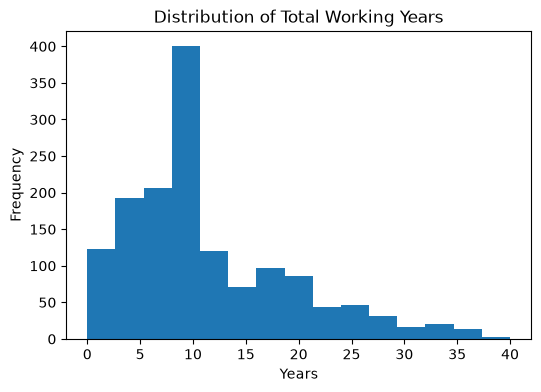

In [193]:
plt.figure(figsize=(6,4))
plt.hist(df["TotalWorkingYears"], bins=15)
plt.title("Distribution of Total Working Years")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.show() 
# indicates most employees have about 10 years of working experience

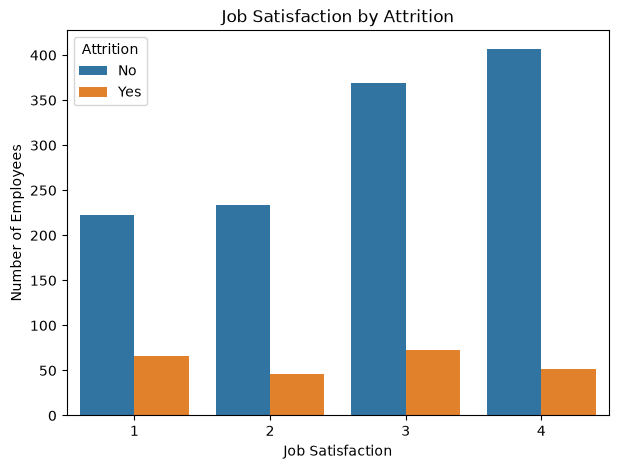

In [194]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")
plt.title("Job Satisfaction by Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")
plt.show() # there is no clear linear relationship between job satisfaction and attrition 

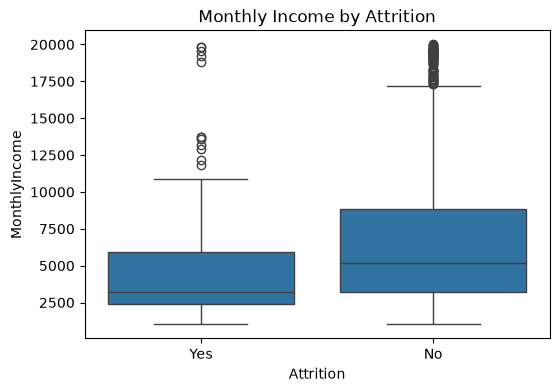

In [195]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income by Attrition")
plt.show()
# indicates median monthly income of employees who left the company were notably lower 
# than those who remained (however there are outliers for both those who stayed and left)

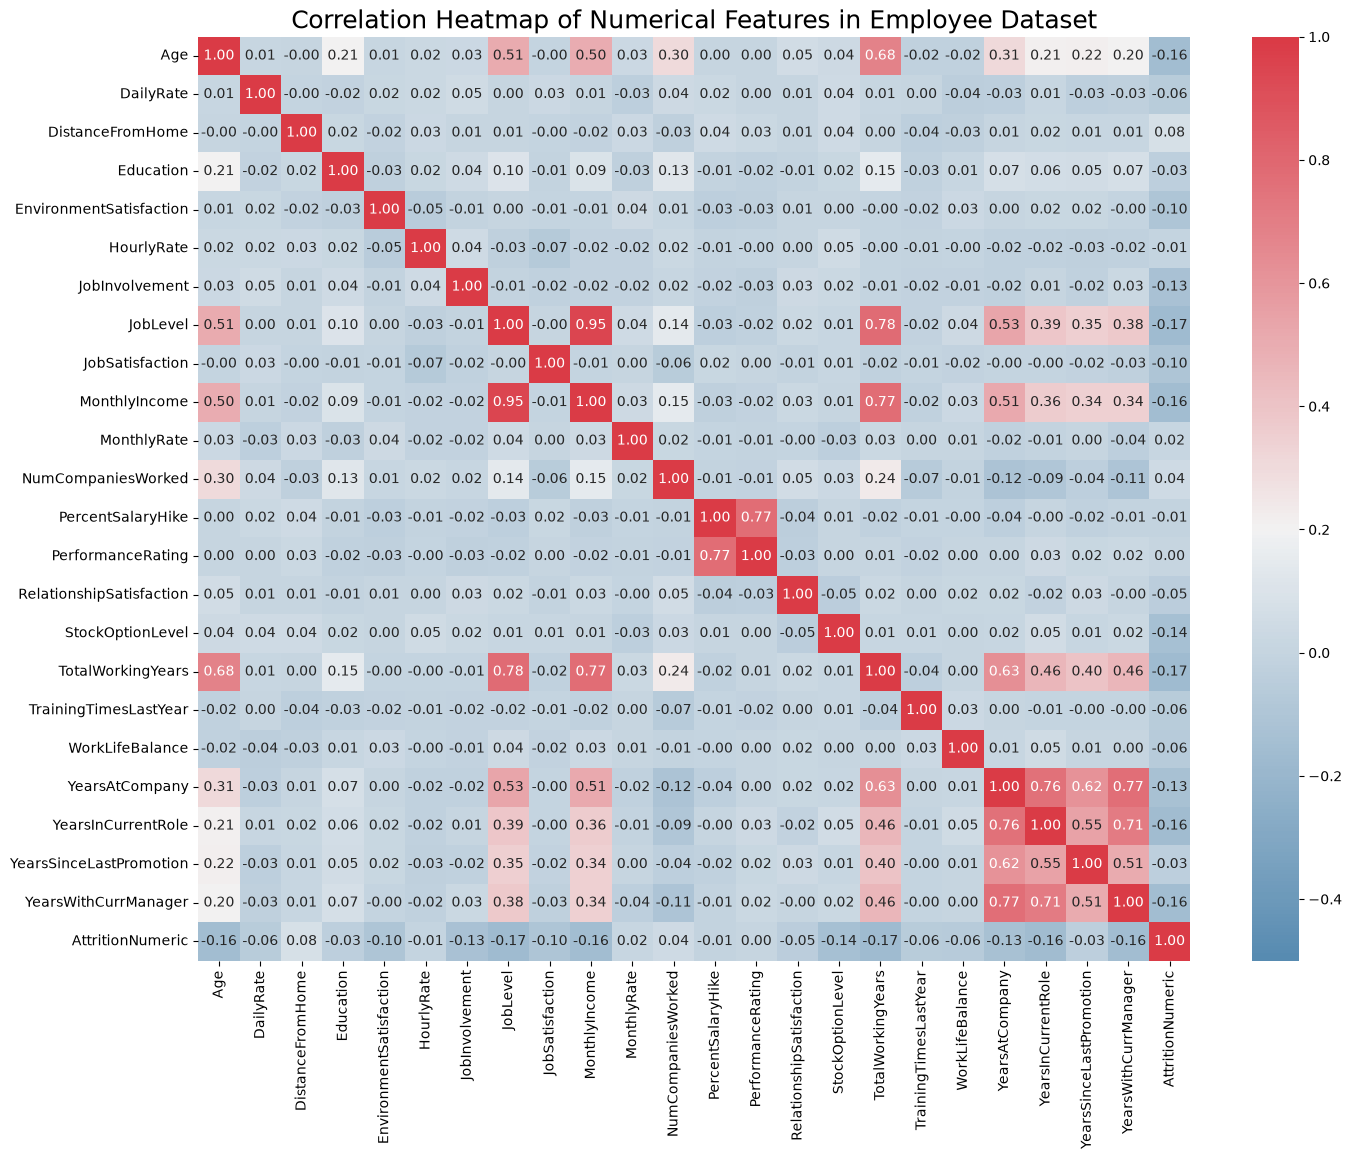

In [196]:
# Correlation heatmap
df["AttritionNumeric"] = df["Attrition"].map({"No": 0, "Yes": 1})  # add attrition numeric as column so atttrition will be included in heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
heatmap_employees = sns.heatmap(corr, fmt=".2f", annot=True, center=0.2, vmin=-0.5, vmax=1, cmap= sns.diverging_palette(240, 10, as_cmap=True))
heatmap_employees.set_xticklabels(corr.columns)
heatmap_employees.set_xticklabels(corr.columns)
plt.title("Correlation Heatmap of Numerical Features in Employee Dataset", fontsize=18)
plt.xticks()
plt.show()
# there are strong and moderate positive correlations between various numerical featres - some of which are intuitve - however there are no features with strong correlation to attrition, suggesting that there
# are multiple aspects that influence it rather than a dominant single feature

### Preparing Data for Processing

In [197]:

X = df.drop(columns=["AttritionNumeric", "Attrition"]) # exclude target and AttritionNumeric which was added for heatmap ( and removed "EmployeeCount","EmployeeNumber","Over18","StandardHours" before generating visuals)
y = df["Attrition"] # target

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # split data

In [199]:
# Columns for categorical and numerical data to apply preprocessing required for models
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns
numerical_columns = X_train.select_dtypes(include=["number"]).columns

In [200]:
# Preprocessing for categorical data
preprocessor_cat_cols = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), categorical_columns),
         ("num", "passthrough", numerical_columns)]) # need to include numbers otherwise ColumnTransformer will ignore
# Preprocessing for categorical and numerical data
preprocessor_cat_and_num_cols = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns)])

## Part 2 -  Machine Learning

### Model 1 - Logistic Regression

In [201]:
# Helper function
def print_time(start, end, train=False):
    total_time= end-start
    train_or_test = "Train"
    if train == False:
        train_or_test = "Query"
    print(f"{train_or_test} time: {total_time:.3f} seconds")
    return total_time

def print_accuracy(acc_score, train=False):
    train_or_test = "Training"
    if train == False:
        train_or_test = "Testing"
    print(f"{train_or_test} accuracy: {acc_score:.3f}")
    return acc_score

In [202]:
logistic_model = LogisticRegression(random_state=42)
# Bundle preprocessing and model in a pipeline
pipeline_one = Pipeline(steps =[("preprocessor", preprocessor_cat_and_num_cols), ("model", logistic_model)])

model_1_start_time_train = timer()
# Preprocess training data and train model
pipeline_one.fit(X_train, y_train) 
model_1_end_time_train = timer()

train_preds_1 = pipeline_one.predict(X_train) # predict on training data

model_1_start_time_test = timer()
# Preprocess test data and predict target
preds_1 = pipeline_one.predict(X_test)
model_1_end_time_test = timer()

# Calculate and display accuracy
train_acc_1 = print_accuracy(accuracy_score(y_train, train_preds_1), True)
test_acc_1 = print_accuracy(accuracy_score(y_test, preds_1))

# Calculate and display time
total_train_time_model_1 = print_time(model_1_start_time_train, model_1_end_time_train, True)
total_test_time_model_1 = print_time(model_1_start_time_test, model_1_end_time_test)


Training accuracy: 0.902
Testing accuracy: 0.864
Train time: 0.051 seconds
Query time: 0.013 seconds


In [203]:
print(classification_report(y_test, preds_1))

              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294



### Model 2 - Decision Tree 

### Decision Tree with Default Parameters 

In [204]:
default_decision_tree = DecisionTreeClassifier(random_state=42)
# Bundle preprocessing and model in a pipeline
pipeline_two = Pipeline(steps =[("preprocessor", preprocessor_cat_cols), ("model", default_decision_tree)])

model_2_start_time_train = timer()
# Preprocess training data and train model
pipeline_two.fit(X_train, y_train) 
model_2_end_time_train = timer()

train_preds_2 = pipeline_two.predict(X_train) # predict on training data

model_2_start_time_test = timer()
# Preprocess test data and predict target
preds_2 = pipeline_two.predict(X_test)
model_2_end_time_test = timer()

# Calculate and display accuracy
train_acc_2 = print_accuracy(accuracy_score(y_train, train_preds_2), True)
test_acc_2 = print_accuracy(accuracy_score(y_test, preds_2))

# Calculate and display time
total_train_time_model_2 = print_time(model_2_start_time_train, model_2_end_time_train, True)
total_test_time_model_2 = print_time(model_2_start_time_test, model_2_end_time_test)
# training accuracy is perfect while testing accuracy is about 0.769 - indicates overfitting

Training accuracy: 1.000
Testing accuracy: 0.769
Train time: 0.052 seconds
Query time: 0.004 seconds


### Testing Max_depth

In [205]:
train_accuracies = []
test_accuracies = []
for depth in range(1, 20):
    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    tree_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor_cat_cols), ("model", tree_model)
        ])

    tree_pipeline.fit(X_train, y_train)

    train_preds_tree = tree_pipeline.predict(X_train) # predict on training data
    preds_tree = tree_pipeline.predict(X_test)
    train_acc_tree = print_accuracy(accuracy_score(y_train, train_preds_tree), True)
    test_acc_tree = print_accuracy(accuracy_score(y_test, preds_tree))
    train_accuracies.append(train_acc_tree)
    test_accuracies.append(test_acc_tree)

Training accuracy: 0.847
Testing accuracy: 0.799
Training accuracy: 0.854
Testing accuracy: 0.806
Training accuracy: 0.867
Testing accuracy: 0.837
Training accuracy: 0.878
Testing accuracy: 0.810
Training accuracy: 0.891
Testing accuracy: 0.833
Training accuracy: 0.908
Testing accuracy: 0.799
Training accuracy: 0.936
Testing accuracy: 0.830
Training accuracy: 0.953
Testing accuracy: 0.816
Training accuracy: 0.966
Testing accuracy: 0.806
Training accuracy: 0.980
Testing accuracy: 0.796
Training accuracy: 0.986
Testing accuracy: 0.789


Training accuracy: 0.989
Testing accuracy: 0.786
Training accuracy: 0.991
Testing accuracy: 0.789
Training accuracy: 0.994
Testing accuracy: 0.776
Training accuracy: 0.997
Testing accuracy: 0.803
Training accuracy: 0.999
Testing accuracy: 0.769
Training accuracy: 0.999
Testing accuracy: 0.765
Training accuracy: 1.000
Testing accuracy: 0.769
Training accuracy: 1.000
Testing accuracy: 0.769


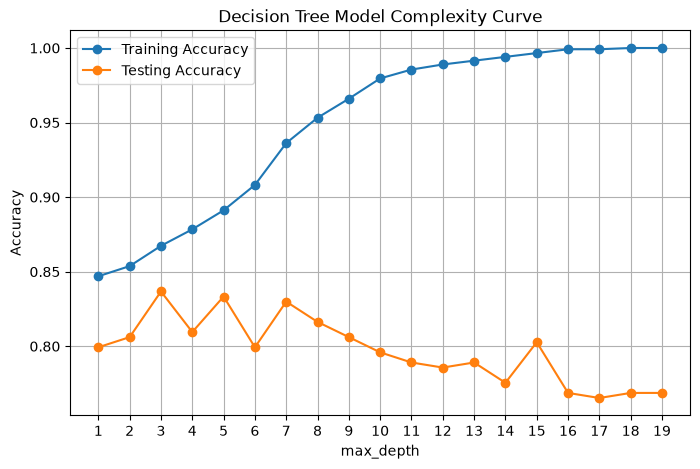

In [206]:
depths = range(1, 20)
plt.figure(figsize=(8, 5))
plt.plot(depths, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(depths,test_accuracies,marker="o", label="Testing Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Model Complexity Curve")
plt.xticks(depths)
plt.grid(True)
plt.legend() # show key for colours corresponding to training and testing accuracy
plt.show()
# max_depth of 3 has highest testing accuracy of approximately 84%

### Final Decision Tree

In [207]:
final_decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
# Bundle preprocessing and model in a pipeline
pipeline_two_final = Pipeline(steps =[("preprocessor", preprocessor_cat_cols), ("model", final_decision_tree)])

model_2_final_start_time_train = timer()
# Preprocess training data and train model
pipeline_two_final.fit(X_train, y_train) 
model_2_final_end_time_train = timer()

train_preds_2_final = pipeline_two_final.predict(X_train) # predict on training data

model_2_final_start_time_test = timer()
# Preprocess test data and predict target
preds_2_final = pipeline_two_final.predict(X_test)
model_2_final_end_time_test = timer()

# Calculate and display accuracy
train_acc_2_final = print_accuracy(accuracy_score(y_train, train_preds_2_final), True)
test_acc_2_final = print_accuracy(accuracy_score(y_test, preds_2_final))

# Calculate and display time
total_train_time_model_2_final = print_time(model_2_final_start_time_train, model_2_final_end_time_train, True)
total_test_time_model_2_final = print_time(model_2_final_start_time_test, model_2_final_end_time_test)

Training accuracy: 0.867
Testing accuracy: 0.837
Train time: 0.026 seconds
Query time: 0.007 seconds
